## Replicating Sloan (1996)

In this exercise, we replicate a simplified version of the seminal study by [Sloan (1996)](https://www.jstor.org/stable/248290), one of the most cited papers in accounting and finance research on the *accrual anomaly*.

**Background.** Sloan asks whether the persistence of current earnings depends on how that earnings figure was generated. He decomposes earnings into an *accrual* component (the non-cash part, driven by changes in working-capital accounts and depreciation) and a *cash flow* component. He shows that earnings performance attributable to accruals is less persistent than earnings performance attributable to cash flow — yet stock prices behave as if investors "fixate" on the bottom-line earnings number without distinguishing between the two. As a result, firms with relatively high (low) accruals go on to earn negative (positive) abnormal stock returns as the market's naive expectations are corrected, particularly around subsequent earnings announcements.

**Goal of this exercise.** Reconstruct Figure 2 of the paper: the annual return to a hedge portfolio that is long the stock of firms with the lowest accruals and short the stock of firms with the highest accruals, using a firm-year panel of Compustat/CRSP-style data (`data/Sloan_Raw.dta`) spanning 1972–2021. Each row has a firm identifier (`gvkey`), fiscal year, the balance-sheet/income-statement items needed to construct accruals and earnings, a 4-digit industry code (`sicc`), and the stock's return over the year (`ret`).

**What you'll practice.**
- Cleaning a firm-year panel: handling missing values and excluding industries (financials, utilities) where the standard accrual/cash-flow decomposition doesn't apply.
- Constructing accounting variables from raw financial-statement items, including year-over-year changes computed with `groupby` + `.shift()`.
- Forming annual decile portfolios with `groupby` + `pd.qcut`.
- Aggregating portfolio-level returns over time and visualizing them.

**A note on scope.** This is a simplified, teaching-oriented replication rather than an exact reproduction of the paper:
- We use raw buy-and-hold returns instead of Sloan's size-adjusted returns.
- We reproduce only Figure 2 (the hedge-portfolio return plot), not the paper's full set of regressions.

The magnitudes won't match the original exactly, but the qualitative pattern — the hedge portfolio earning a positive return in most years — should come through clearly.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [11]:
df = pd.read_stata("../data/Sloan_Raw.dta")
df['fyear'] = df['fyear'].astype(int)

### Step 1. Prepare the dataset and variables

In [12]:
# delete financial and utility industries
is_financial = df['sicc'].between(6000, 6999)
is_utility = df['sicc'].between(4900, 4999)
df = df[~(is_financial | is_utility)].copy()

In [ ]:
# Define Accruals, CFO and earnings (pages 293-294 of Sloan 1996)

is_consecutive = df.groupby('gvkey')['fyear'].diff() == 1

def yoy_change(col: pd.Series) -> pd.Series:
    return df.groupby('gvkey')[col].shift(1).where(is_consecutive)

d_ca = yoy_change('act')
d_cash = yoy_change('che')
d_cl = yoy_change('lct')
df['dlc'] = df['dlc'].fillna(0)
d_std = yoy_change('dlc')
df['txp'] = df['txp'].fillna(0)
d_tp = yoy_change('txp')

avg_at = ((df['at'] + df.groupby('gvkey')['at'].shift()) / 2).where(is_consecutive)

accruals = (d_ca - d_cash) - (d_cl - d_std - d_tp) - df['dp']

df['accruals'] = accruals / avg_at

In [ ]:
# Drop rows with missing key variables
df = df.dropna(subset=['accruals', 'ret']).reset_index(drop=True)

### Step 2: Define Portfolios

In [31]:
# Ranking into deciles by year
df['decile'] = (
    df.groupby('fyear')['accruals']
      .transform(lambda x: pd.qcut(x, 10, labels=False)) + 1
)

In [32]:
df['decile'].value_counts()

decile
1     19906
10    19900
5     19881
8     19881
2     19879
4     19877
3     19873
9     19871
6     19871
7     19869
Name: count, dtype: int64

In [16]:
# Keep extreme deciles based on ACC
extreme = df[df['decile'].isin([1, 10])].copy()

In [17]:
# Hedge portfolio returns (long lowest accrual decile, short highest)
portfolio_returns = extreme.groupby(['fyear', 'decile'])['ret'].mean().unstack('decile')

In [18]:
hedge_returns = portfolio_returns[1] - portfolio_returns[10]

### Step 3: Draw the yearly hedge returns similar to Table 6 and Figure 2 of Sloan (1996)

In [45]:
from scipy.stats import ttest_1samp

annual_port_ret = (
    df.groupby(["fyear", "decile"], as_index=False)
      .agg(
          ret=("ret", "mean"),
          n=("ret", "count")
      )
)

def portfolio_stats(x):
    x = x.dropna()

    mean = x.mean()
    tstat = ttest_1samp(x, popmean=0).statistic

    return pd.Series({
        "return": mean,
        "tstat": tstat,
        "n_years": len(x)
    })


table = (
    annual_port_ret
    .groupby("decile")["ret"]
    .apply(portfolio_stats)
    .unstack()
)
table['n_years'] = table['n_years'].astype(int)

In [46]:
wide = annual_port_ret.pivot(
    index="fyear",
    columns="decile",
    values="ret"
)

hedge = wide[1] - wide[10]
hedge_stats = portfolio_stats(hedge)
table.loc["Hedge"] = hedge_stats

In [47]:
print(table)

          return     tstat  n_years
decile                             
1       0.143762  2.483826     55.0
2       0.147924  3.274135     55.0
3       0.147710  3.455075     55.0
4       0.132264  3.410525     55.0
5       0.158294  3.943420     55.0
6       0.151302  4.101495     55.0
7       0.159176  4.018952     55.0
8       0.167149  4.350630     55.0
9       0.175446  4.366752     55.0
10      0.152275  3.644980     55.0
Hedge  -0.008513 -0.345896     55.0


Sloan (1996) uses *size-adjusted* returns for Figure 2 (subtracting the return on a matched size-decile portfolio). Our dataset only has raw buy-and-hold returns (`ret`) instead, so the magnitudes won't match the original exactly.

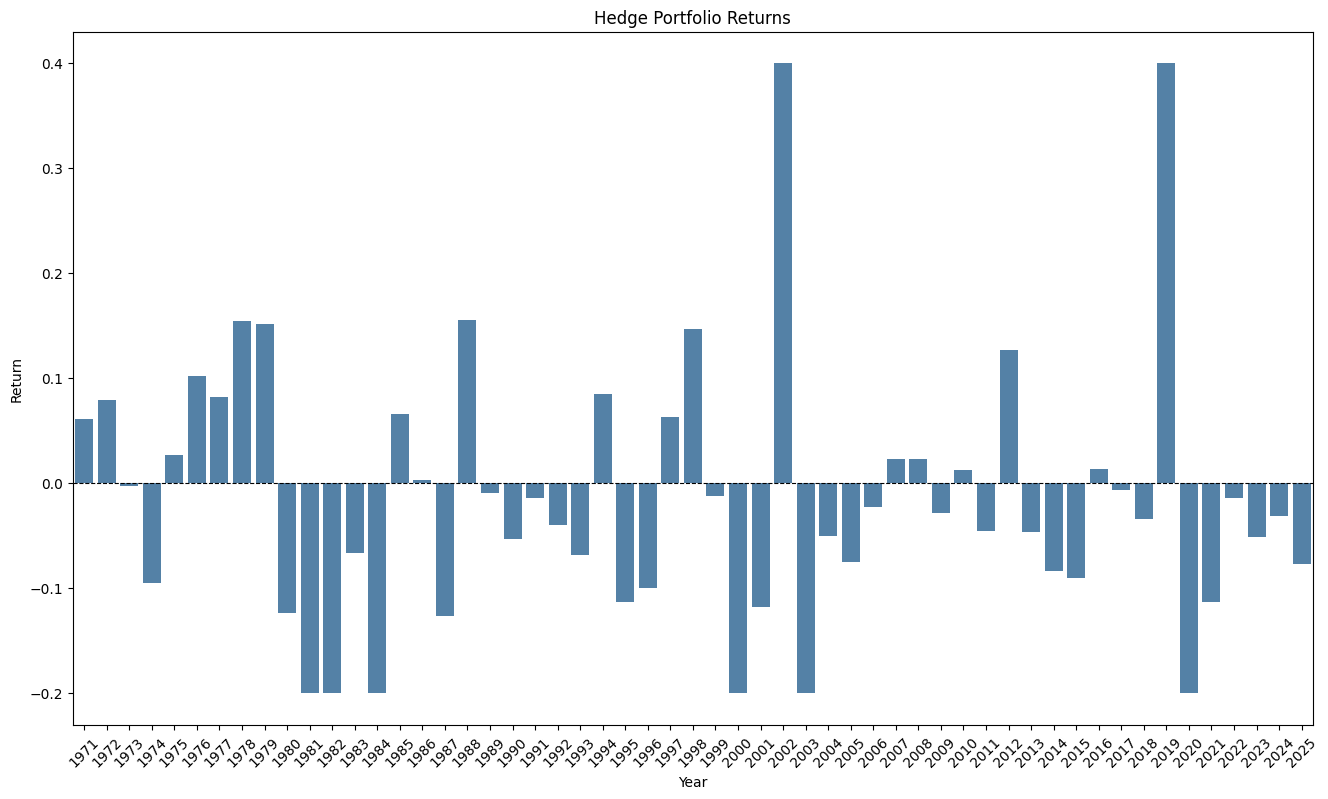

In [ ]:
plt.figure(figsize=(16, 9))
sns.barplot(x=hedge_returns.index, 
            y=hedge_returns.clip(-0.2, 0.4), 
            color='steelblue')
plt.axhline(0, color='black', linewidth=0.8)

plt.title('Hedge Portfolio Returns')
plt.xlabel('Year')
plt.ylabel('Return')
plt.xticks(rotation=45)
plt.show()